In [200]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [201]:
torch.manual_seed(42)
np.random.seed(42)

print('='*60)
print('PyTorch Regression')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cude' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('='*60)

PyTorch Regression
PyTorch version: 2.11.0+cpu
Device: cpu


<div style='font-size: 30px; color: #01a6ff'>Tensors & Autograd</div>

In [202]:
print('Tensors & Autograd')
print('-'*40)

x = torch.tensor([1.0, 2.0, 3.0])
print(f'Tensor: {x}')
print(f'Shape: {x.shape}\ndtype: {x.dtype}\ndevice: {x.device}')

Tensors & Autograd
----------------------------------------
Tensor: tensor([1., 2., 3.])
Shape: torch.Size([3])
dtype: torch.float32
device: cpu


<div style='font-size: 20px; color: #3456ff; padding-left: 50px'>---><i style='font-size: 20px; color: #ff6a00'>requires_grad=True </i>tells PyTorch to track operations for backprop</div>

In [203]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)

#### Forward Pass

In [204]:
y_pred = w * x + b
loss = ((y_pred - torch.tensor([3.0, 5.0, 7.0])) ** 2).mean()

print(f'Forward pass -> loss: {loss.item():.4f}')

Forward pass -> loss: 0.2500


#### Backward Pass --- d(loss)/d(w) and d(loss)/d(b)

In [205]:
loss.backward()

print(f'Gradient w.r.t w: {w.grad.item():.4f}')
print(f'Gradient w.r.t b: {b.grad.item():.4f}')

Gradient w.r.t w: -2.0000
Gradient w.r.t b: -1.0000


<img src='../../../Math/backward_pass.jpeg' width='600'></img>

<div style='text-align: center'>
PyTorch does NOT replace old gradients during backward().
It ADDS new gradients to existing ones.
<div style='color: #12c918'>
So without zeroing:
<i>
old_grad + new_grad <b><div style='color: #b60606'>Accumulation</div> happens during .backward()</b>
</i>
That makes gradients incorrect for the next traning step.
Therefore before each new backward():
<i>
w.zero_grad()
</i>
clears old gradients so the new backward pass stores only the current gradient.
</div>
</div>

In [206]:
w.grad.zero_()
b.grad.zero_()
print('Gradients zeroed!')

Gradients zeroed!


<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'>SECTION 2: Linear Regression From Scratch</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

In [207]:
print("SECTION 2: Linear Regression from Scratch")
print("-" * 40)

SECTION 2: Linear Regression from Scratch
----------------------------------------


### True relationship: y = 3x + 2 + noise

In [208]:
X_raw = torch.linspace(0, 10, 100)

In [209]:
X_raw

tensor([ 0.0000,  0.1010,  0.2020,  0.3030,  0.4040,  0.5051,  0.6061,  0.7071,
         0.8081,  0.9091,  1.0101,  1.1111,  1.2121,  1.3131,  1.4141,  1.5152,
         1.6162,  1.7172,  1.8182,  1.9192,  2.0202,  2.1212,  2.2222,  2.3232,
         2.4242,  2.5253,  2.6263,  2.7273,  2.8283,  2.9293,  3.0303,  3.1313,
         3.2323,  3.3333,  3.4343,  3.5354,  3.6364,  3.7374,  3.8384,  3.9394,
         4.0404,  4.1414,  4.2424,  4.3434,  4.4444,  4.5455,  4.6465,  4.7475,
         4.8485,  4.9495,  5.0505,  5.1515,  5.2525,  5.3535,  5.4545,  5.5556,
         5.6566,  5.7576,  5.8586,  5.9596,  6.0606,  6.1616,  6.2626,  6.3636,
         6.4646,  6.5657,  6.6667,  6.7677,  6.8687,  6.9697,  7.0707,  7.1717,
         7.2727,  7.3737,  7.4747,  7.5758,  7.6768,  7.7778,  7.8788,  7.9798,
         8.0808,  8.1818,  8.2828,  8.3838,  8.4848,  8.5859,  8.6869,  8.7879,
         8.8889,  8.9899,  9.0909,  9.1919,  9.2929,  9.3939,  9.4949,  9.5960,
         9.6970,  9.7980,  9.8990, 10.00

In [210]:
X_raw.shape

torch.Size([100])

<div style='font-size: 20px;text-align: center'>
PyTorch expects:<br><br>

x: (batch_size, features)<br>
w: (features, 1)<br><br>
So matrix multiplication works cleanly.
</div>

In [211]:
X_raw.unsqueeze_(1)
y_raw = 3 * X_raw + 2 + torch.rand_like(X_raw) * 1.5

print('X_raw Unsqueezed!!!')
print(f"X shape: {X_raw.shape}, y shape: {y_raw.shape}")

X_raw Unsqueezed!!!
X shape: torch.Size([100, 1]), y shape: torch.Size([100, 1])


##### What torch.rand_like(X_raw) does

<div style='color: #0b447e'>It creates a tensor with the same shape as X_raw, but filled with random numbers</div>

#### --- Initialize parameters manually ---

In [212]:
W = torch.rand(1, 1, requires_grad=True)
B = torch.rand(1, requires_grad=True)

LR = 0.01
EPOCHS = 500
losses_scratch = []

#### ---Training Loop---

In [213]:
for epoch in range(EPOCHS):
    # “W and B are the starting points,
    # but everything between them and the loss is also tracked”
    y_pred = X_raw @ W + B
    loss = ((y_pred - y_raw)**2).mean()

    loss.backward()
    '''
    W ─┐
    * → +
    x ─┘     │
            → loss
    B ───────┘
    '''

    # PyTorch avoids tracking weight updates (including LR)
    # because they are external optimization rules,
    # not part of the function whose gradient we are computing.
    with torch.no_grad():
        W -= LR * W.grad
        B -= LR * B.grad
        W.grad.zero_()
        B.grad.zero_()

    losses_scratch.append(loss.item())

In [214]:
print(f"Learned  W: {W.item():.4f}  (true: 3.0)")
print(f"Learned  B: {B.item():.4f}  (true: 2.0)")
print(f"Final loss: {losses_scratch[-1]:.4f}")

Learned  W: 2.9975  (true: 3.0)
Learned  B: 2.7487  (true: 2.0)
Final loss: 0.1937


<div style='text-align: center; font-size:30px; color: #39023f'>
Linear Regression<br>
    ↓<br>
Polynomial Regression<br>
    ↓<br>
Multiple Regression<br>
    ↓<br>
Multiple Polynomial Regression<br>
    ↓<br>
Neural Networks<br>
</div>

<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'>SECTION 3: Linear Regression with nn.Module</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

In [215]:
print("SECTION 3: Linear Regression with nn.Module")
print("-" * 40)

SECTION 3: Linear Regression with nn.Module
----------------------------------------


In [216]:
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
dataset = RegressionDataset(X_raw, y_raw)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

#### Manual way

In [217]:
class LinearRegression(nn.Module):
    def __init__(self, in_features=1, out_features=1):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return self.linear(x)
    
model = LinearRegression().to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

print(f"Model architecture:\n{model}")
print(f"Parameters: {sum(p.numel() for p in model.parameters())} total")

Model architecture:
LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)
Parameters: 2 total


### Sequential way

In [218]:
model_shoct = nn.Sequential(
    nn.Linear(1, 1)
)

<div style='color: #0a9696; font-size: 30px'>Training Loop (proper pattern)</div>

In [219]:
losses_module = []
EPOCHS = 200

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses_module.append(epoch_loss / len(dataloader))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {losses_module[-1]:.4f}")

model.eval()
with torch.no_grad():
    w_learned = model.linear.weight.item()
    b_learned = model.linear.bias.item()

print(f"\nLearned W: {w_learned:.4f} (true: 3.0)")
print(f"Learned B: {b_learned:.4f} (true: 2.0)")

Epoch  50 | Loss: 0.2535
Epoch 100 | Loss: 0.2053
Epoch 150 | Loss: 0.2157
Epoch 200 | Loss: 0.1970

Learned W: 2.9918 (true: 3.0)
Learned B: 2.9080 (true: 2.0)


<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'> SECTION 4: Polynomial Regression</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

In [220]:
print('Section 4: Polynomial Regression')
print('-'*40)

Section 4: Polynomial Regression
----------------------------------------


In [221]:
X_poly_raw = torch.linspace(-3, 3, 120).unsqueeze(1)
y_poly = (0.5 * X_poly_raw**3 - 2*X_poly_raw + X_poly_raw + 1 + torch.rand_like(X_poly_raw) * 0.8)

def make_poly_features(X, degree=3):
    return torch.cat([X ** i for i in range(1, degree + 1)], dim=1)

degree = 3
X_poly_feat = make_poly_features(X_poly_raw, degree)

#### --- Normalize features because powers explode: (crucial for polynomial regression stability) ---

In [222]:
X_mean = X_poly_feat.mean(dim=0)
X_std = X_poly_feat.std(dim=0)
X_poly_norm = (X_poly_feat - X_mean) / X_std

poly_model = nn.Linear(degree, 1)
poly_criterion = nn.MSELoss()
poly_optimizer = optim.Adam(poly_model.parameters(), lr=0.05)

In [223]:
losses_poly = []
for epoch in range(500):
    poly_optimizer.zero_grad()
    pred = poly_model(X_poly_norm)
    loss = poly_criterion(pred, y_poly)
    loss.backward()
    poly_optimizer.step()
    losses_poly.append(loss.item())

print(f"Polynomial degree-{degree} regression trained.")
print(f"Final loss: {losses_poly[-1]:.4f}")

Polynomial degree-3 regression trained.
Final loss: 0.0494


<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'>SECTION 5: Multiple Linear Regression</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

In [224]:
print('Section 5: Multiple Linear Regression')
print('-'*40)

Section 5: Multiple Linear Regression
----------------------------------------


In [225]:
N = 200
X_multi = torch.randn(N, 3)
true_weights = torch.tensor([2.0, -3.0, 1.5])
true_bias = 5.0
y_multi = X_multi @ true_weights + true_bias + torch.randn(N) * 0.5

In [226]:
y_multi.shape

torch.Size([200])

In [227]:
y_multi.unsqueeze_(1)
print()

In [228]:
split = int(0.8*N)
X_train, X_test = X_multi[:split], X_multi[split:]
y_train, y_test = y_multi[:split], y_multi[split:]

multi_model = nn.Linear(3, 1)
multi_criterion = nn.MSELoss()
multi_optimizer = optim.Adam(multi_model.parameters(), lr=0.05)

In [229]:
train_losses, test_losses = [], []

for epoch in range(300):
    multi_model.train()
    multi_optimizer.zero_grad()
    pred = multi_model(X_train)
    loss = multi_criterion(pred, y_train)
    loss.backward()
    multi_optimizer.step()
    train_losses.append(loss.item())

    multi_model.eval()
    with torch.no_grad():
        val_loss = multi_criterion(multi_model(X_test), y_test)
    test_losses.append(val_loss.item())

learned_w = multi_model.weight.data.squeeze()
learned_b = multi_model.bias.data.item()
print(f"Learned weights:{learned_w.tolist()} (true: [2.0, -3.0, 1.5])")
print(f"Learned bias:{learned_b:.4f}  (true: 5.0)")
print(f"Test  MSE:{test_losses[-1]:.4f}")

Learned weights:[1.9349061250686646, -2.9833993911743164, 1.5181065797805786] (true: [2.0, -3.0, 1.5])
Learned bias:4.9952  (true: 5.0)
Test  MSE:0.2771


In [230]:
multi_model.eval()
with torch.no_grad():
    y_hat = multi_model(X_test)
    ss_res = ((y_test - y_hat)**2).sum()
    ss_tot = ((y_test - y_test.mean())**2).sum()
    r2 = 1 - ss_res / ss_tot

print(f"R² Score:  {r2.item():.4f}")

R² Score:  0.9789


<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'> SECTION 6: Logistic Regression (Binary Classification)</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

In [231]:
print("SECTION 6: Logistic Regression")
print("-" * 40)


from sklearn.datasets import make_classification
X_cls_np, y_cls_np = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_clusters_per_class=1, random_state=42
)

X_cls = torch.tensor(X_cls_np, dtype=torch.float32)
y_cls = torch.tensor(y_cls_np, dtype=torch.float32).unsqueeze(1)
 
split = 240
X_tr, X_te = X_cls[:split], X_cls[split:]
y_tr, y_te = y_cls[:split], y_cls[split:]
 
class LogisticRegression(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)
 
    def forward(self, x):
        return torch.sigmoid(self.linear(x)) 
 
log_model = LogisticRegression(2)
log_criterion = nn.BCELoss()            
log_optimizer = optim.Adam(log_model.parameters(), lr=0.1)
 
log_losses = []
for epoch in range(300):
    log_model.train()
    log_optimizer.zero_grad()
    pred = log_model(X_tr)
    loss = log_criterion(pred, y_tr)
    loss.backward()
    log_optimizer.step()
    log_losses.append(loss.item())
 
log_model.eval()
with torch.no_grad():
    test_pred  = log_model(X_te)
    pred_class = (test_pred >= 0.5).float()
    accuracy   = (pred_class == y_te).float().mean()
 
print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

SECTION 6: Logistic Regression
----------------------------------------
Test Accuracy: 93.33%


<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'>SECTION 7:  Multiple Polynomial Regression</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

In [232]:
# ════════════════════════════════════════════════════════════
# Multiple Polynomial Regression
# y = 2*x1² - 3*x2 + 1.5*x1*x2 + 4 + noise
# ════════════════════════════════════════════════════════════

torch.manual_seed(42)

N = 300

X = torch.randn(N, 2)

x1 = X[:, 0:1]
x2 = X[:, 1:2]

y = (
    2 * x1**2
    - 3 * x2
    + 1.5 * x1 * x2
    + 4
    + torch.randn_like(x1) * 0.5
)

def make_multi_poly_features(X):
    x1 = X[:, 0:1]
    x2 = X[:, 1:2]

    return torch.cat([
        x1,
        x2,
        x1**2,
        x2**2,
        x1 * x2
    ], dim=1)

X_poly = make_multi_poly_features(X)

print("Polynomial feature shape:", X_poly.shape)

X_multi_mean = X_poly.mean(dim=0)
X_multi_std  = X_poly.std(dim=0)

X_poly = (X_poly - X_multi_mean) / X_multi_std


split = int(0.8 * N)

X_multi_poly_train = X_poly[:split]
X_multi_poly_test  = X_poly[split:]

y_multi_poly_train = y[:split]
y_multi_poly_test  = y[split:]

model = nn.Linear(5, 1)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.05)

EPOCHS = 500

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    y_multi_poly_pred = model(X_multi_poly_train)
    loss = criterion(y_multi_poly_pred, y_multi_poly_train)

    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f}")

model.eval()

with torch.no_grad():
    test_pred = model(X_multi_poly_test)
    test_loss = criterion(test_pred, y_multi_poly_test)
    print("\nTest Loss:", round(test_loss.item(), 4))

    print("\nLearned Parameters:")
    print("Weights:", model.weight.data.squeeze())
    print("Bias:", model.bias.data.item())

with torch.no_grad():
    ss_res = ((y_multi_poly_test - test_pred) ** 2).sum()
    ss_tot = ((y_test - y_test.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot

print(f"\nR² Score: {r2.item():.4f}")

Polynomial feature shape: torch.Size([300, 5])
Epoch 100 | Loss: 2.8793
Epoch 200 | Loss: 0.2626
Epoch 300 | Loss: 0.2226
Epoch 400 | Loss: 0.2225
Epoch 500 | Loss: 0.2225

Test Loss: 0.2726

Learned Parameters:
Weights: tensor([ 0.0089, -2.8229,  2.6497, -0.0032,  1.4343])
Bias: 5.834493160247803

R² Score: 0.9689


<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'>SECTION 8: Model Saving & Loading</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

In [233]:
print('SECTION 8: Model Saving & Loading')
print('-'*40)

SECTION 8: Model Saving & Loading
----------------------------------------


In [234]:
torch.save(model.state_dict(), 'linear_model.pth')

##### Method 2: Save entire model (less portable)

In [235]:
torch.save(model, 'Linear_model_full.pth')
checkpoint = {
    "epoch": EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": losses_module[-1],
}
torch.save(checkpoint, "checkpoint.pth")
print("Saved checkpoint!!!")

Saved checkpoint!!!


<div style='color: #05124d'>
════════════════════════════════════════════════════════════
</div>
<i style='color: #123456;font-size: 30px'>SECTION 9: Visualization</i>
<div style='color: #071140'>
════════════════════════════════════════════════════════════
</div>

SECTION 9: Generating Visualizations...
Saved → pytorch_regression_plots.png


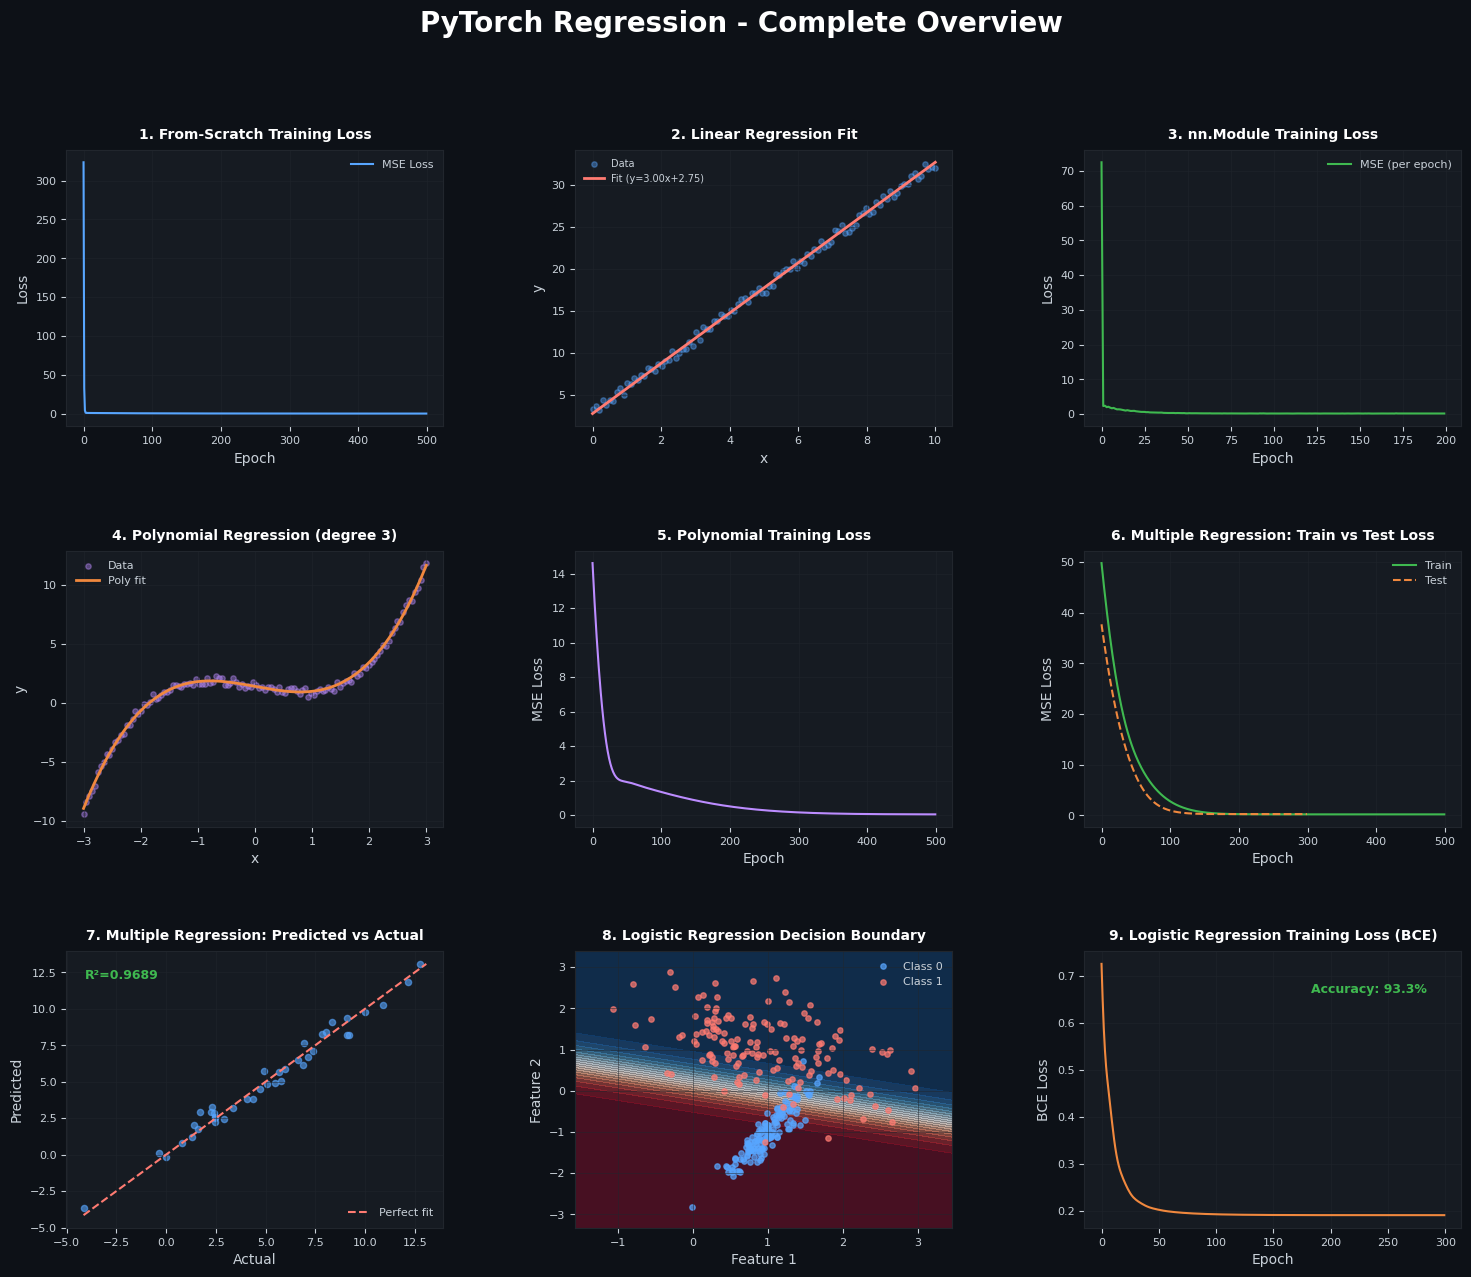

In [237]:
print("SECTION 9: Generating Visualizations...")

fig = plt.figure(figsize=(18, 14), facecolor='#0d1117')
fig.suptitle('PyTorch Regression - Complete Overview', fontsize=20,
             color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ACCENT   = "#58a6ff"
GREEN    = "#3fb950"
ORANGE   = "#f0883e"
PURPLE   = "#bc8cff"
RED      = "#ff7b72"
BG_PANEL = "#161b22"
GRID_CLR = "#21262d"
TEXT_CLR = "#c9d1d9"

def style_ax(ax, title):
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=TEXT_CLR, labelsize=8)
    ax.set_title(title, color="white", fontsize=10, fontweight="bold", pad=8)
    ax.xaxis.label.set_color(TEXT_CLR)
    ax.yaxis.label.set_color(TEXT_CLR)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_CLR)
    ax.grid(True, color=GRID_CLR, linewidth=0.5, alpha=0.7)

# ── Plot 1: Scratch training curve ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, "1. From-Scratch Training Loss")
ax1.plot(losses_scratch, color=ACCENT, linewidth=1.5, label="MSE Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(framealpha=0, labelcolor=TEXT_CLR, fontsize=8)
 
# ── Plot 2: Scratch regression line ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "2. Linear Regression Fit")
with torch.no_grad():
    x_line = torch.linspace(0, 10, 100).unsqueeze(1)
    y_line = x_line @ W + B
ax2.scatter(X_raw.numpy(), y_raw.numpy(), color=ACCENT, alpha=0.4, s=15, label="Data")
ax2.plot(x_line.numpy(), y_line.numpy(), color=RED, linewidth=2, label=f"Fit (y={W.item():.2f}x+{B.item():.2f})")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.legend(framealpha=0, labelcolor=TEXT_CLR, fontsize=7)
 
# ── Plot 3: nn.Module training loss ──────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3, "3. nn.Module Training Loss")
ax3.plot(losses_module, color=GREEN, linewidth=1.5, label="MSE (per epoch)")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Loss")
ax3.legend(framealpha=0, labelcolor=TEXT_CLR, fontsize=8)
 
# ── Plot 4: Polynomial data + fit ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
style_ax(ax4, "4. Polynomial Regression (degree 3)")
poly_model.eval()
with torch.no_grad():
    X_line_p = torch.linspace(-3, 3, 200).unsqueeze(1)
    X_line_f = make_poly_features(X_line_p, degree)
    X_line_n = (X_line_f - X_mean) / X_std
    y_line_p = poly_model(X_line_n)
ax4.scatter(X_poly_raw.numpy(), y_poly.numpy(), color=PURPLE, alpha=0.4, s=15, label="Data")
ax4.plot(X_line_p.numpy(), y_line_p.numpy(), color=ORANGE, linewidth=2, label="Poly fit")
ax4.set_xlabel("x"); ax4.set_ylabel("y")
ax4.legend(framealpha=0, labelcolor=TEXT_CLR, fontsize=8)
 
# ── Plot 5: Polynomial loss ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
style_ax(ax5, "5. Polynomial Training Loss")
ax5.plot(losses_poly, color=PURPLE, linewidth=1.5)
ax5.set_xlabel("Epoch"); ax5.set_ylabel("MSE Loss")
 
# ── Plot 6: Multiple regression train vs test ─────────────────
ax6 = fig.add_subplot(gs[1, 2])
style_ax(ax6, "6. Multiple Regression: Train vs Test Loss")
ax6.plot(train_losses, color=GREEN, linewidth=1.5, label="Train")
ax6.plot(test_losses,  color=ORANGE, linewidth=1.5, label="Test", linestyle="--")
ax6.set_xlabel("Epoch"); ax6.set_ylabel("MSE Loss")
ax6.legend(framealpha=0, labelcolor=TEXT_CLR, fontsize=8)
 
# ── Plot 7: Multiple regression predictions vs actual ──────────
ax7 = fig.add_subplot(gs[2, 0])
style_ax(ax7, "7. Multiple Regression: Predicted vs Actual")
multi_model.eval()
with torch.no_grad():
    y_pred_test = multi_model(X_test).squeeze().numpy()
y_true_test = y_test.squeeze().numpy()
ax7.scatter(y_true_test, y_pred_test, color=ACCENT, alpha=0.6, s=20)
lims = [min(y_true_test.min(), y_pred_test.min()), max(y_true_test.max(), y_pred_test.max())]
ax7.plot(lims, lims, color=RED, linewidth=1.5, linestyle="--", label="Perfect fit")
ax7.set_xlabel("Actual"); ax7.set_ylabel("Predicted")
ax7.text(0.05, 0.9, f"R²={r2.item():.4f}", transform=ax7.transAxes,
         color=GREEN, fontsize=9, fontweight="bold")
ax7.legend(framealpha=0, labelcolor=TEXT_CLR, fontsize=8)
 
# ── Plot 8: Logistic regression decision boundary ─────────────
ax8 = fig.add_subplot(gs[2, 1])
style_ax(ax8, "8. Logistic Regression Decision Boundary")
X_np = X_cls.numpy(); y_np = y_cls.squeeze().numpy()
x_min, x_max = X_np[:,0].min()-0.5, X_np[:,0].max()+0.5
y_min, y_max = X_np[:,1].min()-0.5, X_np[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
log_model.eval()
with torch.no_grad():
    zz = log_model(grid).reshape(xx.shape).numpy()
ax8.contourf(xx, yy, zz, levels=20, cmap="RdBu", alpha=0.5)
ax8.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], color=ACCENT, s=15, alpha=0.7, label="Class 0")
ax8.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], color=RED,   s=15, alpha=0.7, label="Class 1")
ax8.set_xlabel("Feature 1"); ax8.set_ylabel("Feature 2")
ax8.legend(framealpha=0, labelcolor=TEXT_CLR, fontsize=8)
 
# ── Plot 9: Logistic regression loss ──────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
style_ax(ax9, "9. Logistic Regression Training Loss (BCE)")
ax9.plot(log_losses, color=ORANGE, linewidth=1.5)
ax9.set_xlabel("Epoch"); ax9.set_ylabel("BCE Loss")
ax9.text(0.6, 0.85, f"Accuracy: {accuracy.item()*100:.1f}%", transform=ax9.transAxes,
         color=GREEN, fontsize=9, fontweight="bold")
 
plt.savefig("pytorch_regression_plots.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
print("Saved → pytorch_regression_plots.png")
 